In [5]:
ls "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/Missing_values_Imputation_Beyesian_Diffusion_Transformer/"

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import CLIPTokenizer
from diffusers import StableDiffusionPipeline
from peft import get_peft_model, LoraConfig, TaskType
from accelerate import Accelerator
from tqdm.auto import tqdm

# ==== CONFIGURATION ====
DATA_CSV = "/mnt/Internal/MedImage/chexpert_balanced_for_training_1000_per_label_dis+demog.csv"

# Configuration parameters
IMAGE_ROOT = "/mnt/Internal/MedImage/unzip_chexpert_images/CheXpert-v1.0/train"
OUTPUT_DIR = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/LORA_prompt_guided_fine_tuning_stable_diffusion_model/"
START_EPOCH = 150
EPOCHS = 200
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
MAX_LENGTH = 77
IMAGE_SIZE = 512
SAVE_EVERY = 1

# ==== DATASET ====
class CheXpertCaptionDataset(Dataset):
    def __init__(self, dataframe, image_root, tokenizer):
        self.dataframe = dataframe
        self.image_root = image_root
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        self.valid_data = []
        for _, row in dataframe.iterrows():
            img_path = os.path.join(image_root, row["Path"].replace("CheXpert-v1.0/train/", ""))
            if os.path.exists(img_path):
                self.valid_data.append((img_path, self.generate_caption(row)))

    def generate_caption(self, row):
        findings = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
                    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
                    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']
        findings_present = [f for f in findings if row.get(f, 0) == 1]
        findings_str = ", ".join(findings_present).lower() if findings_present else "no significant findings"

        gender = "female" if row.get("GENDER_Female", 0) == 1 else "male"
        age_group = next((col.replace("AGE_GROUP_AGE_", "").replace("_", "-") for col in row.index if "AGE_GROUP_AGE_" in col and row[col] == 1), "unknown")
        race_group = next((col.replace("PRIMARY_RACE_", "").replace("_", " ").lower() for col in row.index if "PRIMARY_RACE_" in col and row[col] == 1), "unknown race")

        return f"Grayscale chest X-ray of a {age_group}-year-old {race_group} {gender} patient showing {findings_str}."

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        img_path, caption = self.valid_data[idx]
        image = self.transform(Image.open(img_path).convert("RGB"))
        tokenized = self.tokenizer(caption, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": tokenized.input_ids.squeeze(0),
            "attention_mask": tokenized.attention_mask.squeeze(0)
        }

# ==== TRAINING LOOP ====
def train():
    accelerator = Accelerator()
    device = accelerator.device

    df = pd.read_csv(DATA_CSV)
    df.replace(-1, 1, inplace=True)
    df.replace(np.nan, 0, inplace=True)
    df= df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]

    tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
    dataset = CheXpertCaptionDataset(df, IMAGE_ROOT, tokenizer)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float32)
    pipe.to(device)
    unet = pipe.unet

    lora_config = LoraConfig(r=4, lora_alpha=16, target_modules=["to_q", "to_k", "to_v"], lora_dropout=0.1, bias="none")
    unet = get_peft_model(unet, lora_config)

    optimizer = torch.optim.AdamW(unet.parameters(), lr=LEARNING_RATE)
    unet, optimizer, dataloader = accelerator.prepare(unet, optimizer, dataloader)

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Load weights if resuming
    checkpoint_path = os.path.join(OUTPUT_DIR, f"lora_unet_epoch_{START_EPOCH}.pt")
    if os.path.exists(checkpoint_path):
        print(f"Loading weights from {checkpoint_path}")
        unet.load_state_dict(torch.load(checkpoint_path))
    else:
        print(f"No checkpoint found at {checkpoint_path}, starting from scratch.")

    best_loss = float('inf')  # Initialize best loss

    for epoch in range(START_EPOCH, EPOCHS):
        unet.train()
        total_loss = 0

        for batch in tqdm(dataloader, desc=f"Epoch {epoch + 1}"):
            latents = pipe.vae.encode(batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215
            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, 1000, (latents.shape[0],), device=device).long()
            noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = pipe.text_encoder(batch["input_ids"].to(device)).last_hidden_state
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample
            loss = torch.nn.functional.mse_loss(model_pred, noise)

            accelerator.backward(loss)
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch + 1} Average Loss: {avg_loss:.4f}")

        # Save model every epoch
        save_path = os.path.join(OUTPUT_DIR, f"lora_unet_epoch_{epoch+1}.pt")
        accelerator.save(unet.state_dict(), save_path)
        print(f"Saved LoRA weights to {save_path}")

        # Optionally keep tracking best loss
        if avg_loss < best_loss:
            best_loss = avg_loss
            print(f"New best loss {best_loss:.4f}")

if __name__ == "__main__":
    train()

In [ ]:
#0.1317, 14th epoch
#0.1330, 15th epoch

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import CLIPTokenizer
from diffusers import StableDiffusionPipeline
from peft import get_peft_model, LoraConfig
from accelerate import Accelerator
from tqdm.auto import tqdm
from torch.serialization import add_safe_globals
from peft.utils import PeftType
from peft.tuners.lora import LoraConfig

# ==== CONFIGURATION ====
DATA_CSV = "/mnt/Internal/MedImage/chexpert_balanced_for_training_1000_per_label_dis+demog.csv"
IMAGE_ROOT = "/mnt/Internal/MedImage/unzip_chexpert_images/CheXpert-v1.0/train"
OUTPUT_DIR = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/LORA_prompt_guided_fine_tuning_stable_diffusion_model_with_inrease_LORA_parameters_attention_and_contrastive_loss"
START_EPOCH = 149
EPOCHS = 200
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
MAX_LENGTH = 77
IMAGE_SIZE = 512
SAVE_EVERY = 1

# ==== DATASET ====
class CheXpertCaptionDataset(Dataset):
    def __init__(self, dataframe, image_root, tokenizer):
        self.dataframe = dataframe
        self.image_root = image_root
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        self.valid_data = []
        for _, row in dataframe.iterrows():
            img_path = os.path.join(image_root, row["Path"].replace("CheXpert-v1.0/train/", ""))
            if os.path.exists(img_path):
                self.valid_data.append((img_path, self.generate_caption(row)))

    def generate_caption(self, row):
        findings = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
                    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
                    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']
        findings_present = [f for f in findings if row.get(f, 0) == 1]
        findings_str = ", ".join(findings_present).lower() if findings_present else "no significant findings"

        gender = "female" if row.get("GENDER_Female", 0) == 1 else "male"
        age_group = next((col.replace("AGE_GROUP_AGE_", "").replace("_", "-") for col in row.index if "AGE_GROUP_AGE_" in col and row[col] == 1), "unknown")
        race_group = next((col.replace("PRIMARY_RACE_", "").replace("_", " ").lower() for col in row.index if "PRIMARY_RACE_" in col and row[col] == 1), "unknown race")

        return f"Grayscale chest X-ray of a {age_group}-year-old {race_group} {gender} patient showing {findings_str}."

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        img_path, caption = self.valid_data[idx]
        image = self.transform(Image.open(img_path).convert("RGB"))
        tokenized = self.tokenizer(caption, padding="max_length", truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
        return {
            "pixel_values": image,
            "input_ids": tokenized.input_ids.squeeze(0),
            "attention_mask": tokenized.attention_mask.squeeze(0)
        }

# ==== TRAINING LOOP ====

def train():
    accelerator = Accelerator()
    device = accelerator.device

    df = pd.read_csv(DATA_CSV)
    df.replace(-1, 1, inplace=True)
    df.replace(np.nan, 0, inplace=True)
    df = df[df['Frontal/Lateral'].str.contains('frontal', case=False, na=False)]

    tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
    dataset = CheXpertCaptionDataset(df, IMAGE_ROOT, tokenizer)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float32)
    pipe.to(device)
    unet = pipe.unet

    # Apply LoRA
    lora_config = LoraConfig(
        r=8, lora_alpha=32,
        target_modules=["to_q", "to_k", "to_v", "attn2.to_q", "attn2.to_k", "attn2.to_v", "down_blocks.*.resnets.*"],
        lora_dropout=0.1, bias="none"
    )
    unet = get_peft_model(unet, lora_config)

    # ==== LOAD CHECKPOINT IF EXISTS ====
    if START_EPOCH > 0:
        checkpoint_path = os.path.join(OUTPUT_DIR, f"lora_unet_best_epoch_{START_EPOCH}.pt")
        if os.path.exists(checkpoint_path):
            print(f"Loading model from checkpoint: {checkpoint_path}")
            add_safe_globals([PeftType, LoraConfig])
            checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
            unet.load_state_dict(checkpoint["unet_state_dict"])
            print(f"Resumed training from epoch {START_EPOCH}")
        else:
            print(f"Checkpoint for epoch {START_EPOCH} not found. Starting from scratch.")
    else:
        print("Starting training from scratch.")


    optimizer = torch.optim.AdamW(unet.parameters(), lr=LEARNING_RATE)
    unet, optimizer, dataloader = accelerator.prepare(unet, optimizer, dataloader)

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    best_loss = float("inf")  # Initialize the best loss to infinity

    for epoch in range(START_EPOCH, EPOCHS):
        unet.train()
        total_loss = 0
        for batch in tqdm(dataloader, desc=f"Epoch {epoch + 1}"):
            latents = pipe.vae.encode(batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215

            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, 1000, (latents.shape[0],), device=device).long()
            noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

            encoder_hidden_states = pipe.text_encoder(batch["input_ids"].to(device)).last_hidden_state
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample

            loss = nn.functional.mse_loss(model_pred, noise)
            accelerator.backward(loss)

            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch + 1} Average Loss: {avg_loss:.4f}")

        # Save checkpoint only if the current loss is lower than the best loss
        if avg_loss < best_loss:
            best_loss = avg_loss
            unwrapped_model = accelerator.unwrap_model(unet)
            checkpoint_path = os.path.join(OUTPUT_DIR, f"lora_unet_best_epoch_{epoch+1}.pt")
            torch.save({
                "unet_state_dict": unwrapped_model.state_dict(),
                "lora_config": lora_config,
            }, checkpoint_path)
            print(f"New best model saved at: {checkpoint_path} with loss: {avg_loss:.4f}")

if __name__ == "__main__":
    train()

Loading the model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model loaded successfully!
Generating 5 images for prompt: Chest X-ray of a patient showing Pneumothorax with 100 inference steps


  0%|          | 0/100 [00:00<?, ?it/s]

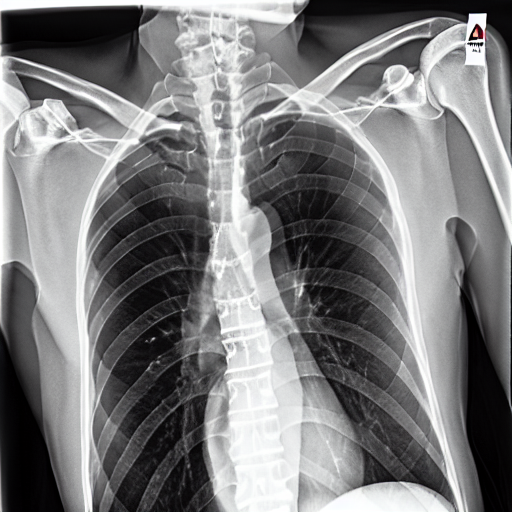

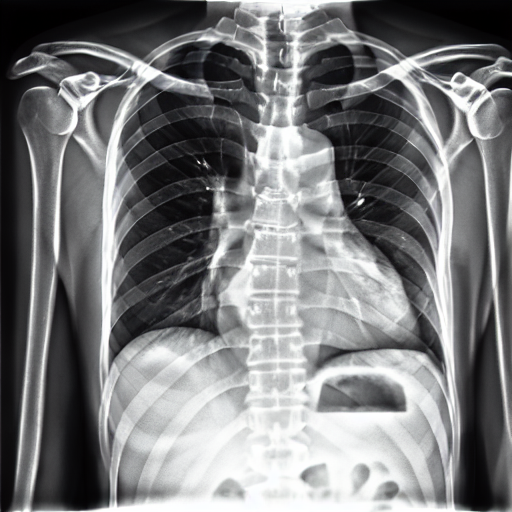

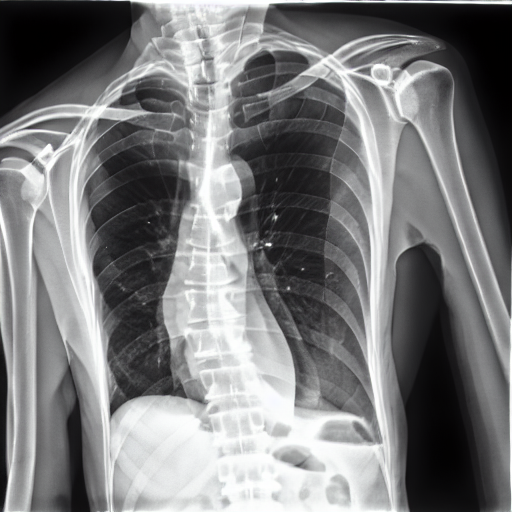

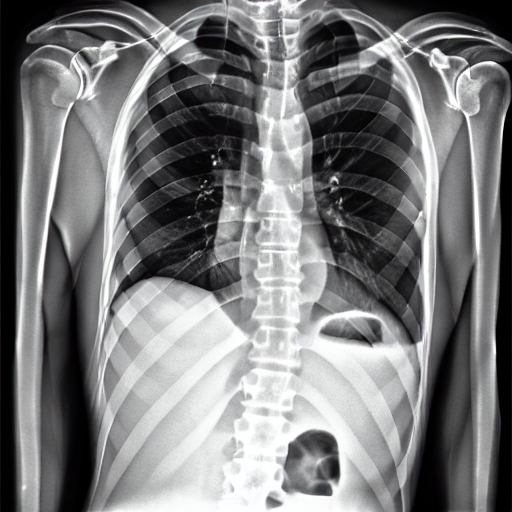

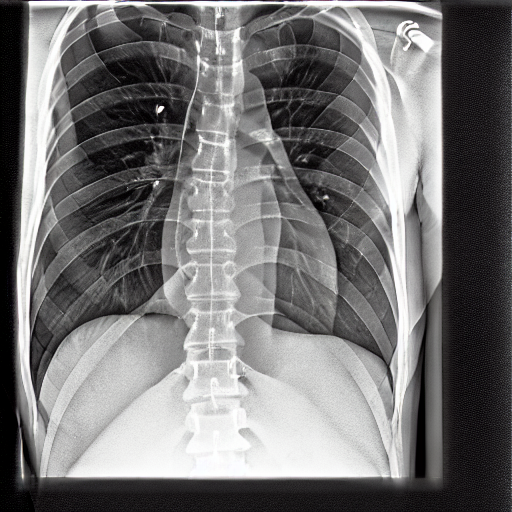

In [1]:
import torch
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model
from PIL import Image
import matplotlib.pyplot as plt

# ==== CONFIGURATION ====
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_PATH = "/mnt/Internal/MedImage/CheXpert Dataset/Lab_Rotation_2/LORA_prompt_guided_fine_tuning_stable_diffusion_model_with_inrease_LORA_parameters_attention_and_contrastive_loss/lora_unet_best_epoch_149.pt"

# ==== LOAD PIPELINE ====
print("Loading the model...")
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float32)
pipe.to(DEVICE)

# ==== APPLY LoRA ====
lora_config = LoraConfig(
    r=8, lora_alpha=32,
    target_modules=["to_q", "to_k", "to_v", "attn2.to_q", "attn2.to_k", "attn2.to_v", "down_blocks.*.resnets.*"],
    lora_dropout=0.1, bias="none"
)
pipe.unet = get_peft_model(pipe.unet, lora_config)

from torch.serialization import add_safe_globals
from peft.tuners.lora import LoraConfig
add_safe_globals([LoraConfig])

# Load the fine-tuned weights
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
pipe.unet.load_state_dict(checkpoint["unet_state_dict"])
print("Model loaded successfully!")

# ==== GENERATE IMAGES ====
def generate_images(prompt, num_images=1, steps=100):
    print(f"Generating {num_images} images for prompt: {prompt} with {steps} inference steps")
    with torch.no_grad():
        result = pipe([prompt] * num_images, guidance_scale=7.5, num_inference_steps=steps)
        images = result.images
        
    for image in images:
        display(image)

# ==== EXAMPLE USAGE ====
#prompt = "Chest X-ray of a 50-70-year-old male patient showing Pneumothorax"
prompt = "Chest X-ray of a patient showing Pneumothorax"

num_images = 5
generate_images(prompt, num_images, steps=100)
